# Modelos Polinómicos y Logarítmicos

La regresión lineal simple asume una relación **estrictamente lineal** entre $X$ e $Y$. Sin embargo, muchos fenómenos reales presentan relaciones curvilíneas que no pueden capturarse con una recta. Los **modelos polinómicos** y **logarítmicos** son extensiones naturales que permiten modelar este tipo de comportamientos, manteniendo la estructura de los modelos lineales en los parámetros.

En este cuaderno estudiaremos:

## Contenido

**Parte 1 — Modelos Polinómicos**
1. Definición y formulación matemática
2. Ajuste del modelo mediante MCO
3. Interpretación de los coeficientes
4. Selección del grado óptimo (underfitting vs. overfitting)
5. Validación de supuestos

**Parte 2 — Modelos Logarítmicos**
1. Definición y tipos de transformaciones logarítmicas
2. Ajuste e interpretación
3. Cuándo usar cada variante
4. Comparación entre modelos

---

> **Idea clave**: Tanto los modelos polinómicos como los logarítmicos son **lineales en los parámetros** aunque no en las variables. Esto permite estimarlos con MCO una vez que se transforman las variables adecuadamente.

In [34]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score
from scipy import stats
from scipy.stats import shapiro

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style="whitegrid", palette="muted")

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


# PARTE 1 — Modelos Polinómicos

## 1.1 Definición y Formulación Matemática

Un **modelo de regresión polinómica de grado $p$** extiende la regresión lineal simple incluyendo potencias de $X$ como variables adicionales:

$$Y_i = \beta_0 + \beta_1 X_i + \beta_2 X_i^2 + \beta_3 X_i^3 + \cdots + \beta_p X_i^p + \varepsilon_i$$

### ¿Por qué sigue siendo un modelo "lineal"?

Aunque la función es curvilínea en $X$, el modelo es **lineal en los parámetros** $\beta_0, \beta_1, \ldots, \beta_p$. Basta con crear nuevas variables:

$$Z_1 = X, \quad Z_2 = X^2, \quad Z_3 = X^3, \quad \ldots$$

y el modelo se convierte en una **regresión lineal múltiple** estándar:

$$Y_i = \beta_0 + \beta_1 Z_{1i} + \beta_2 Z_{2i} + \cdots + \beta_p Z_{pi} + \varepsilon_i$$

Esto permite estimar los coeficientes con MCO directamente.

### Casos especiales

| Grado $p$ | Nombre | Forma de la curva |
|-----------|--------|-------------------|
| 1 | Lineal | Recta |
| 2 | Cuadrático (parábola) | ∪ o ∩ (un punto extremo) |
| 3 | Cúbico | Curva con un punto de inflexión |
| 4+ | Alto orden | Curvas más complejas |

### Cuándo usar un modelo polinómico

- La relación entre $Y$ y $X$ presenta forma de U, arco o curva
- El gráfico de residuos vs. ajustados muestra un patrón sistemático no lineal
- Existe teoría que sugiere una relación curvilínea (ej. rendimientos decrecientes, dosis-respuesta)


## 1.2 Ejemplo Práctico — Consumo de Combustible vs. Velocidad

**Contexto**: El consumo de combustible de un vehículo (litros/100 km) no es lineal respecto a la velocidad. A velocidades muy bajas hay ineficiencia por el ralentí, y a velocidades muy altas aumenta la resistencia aerodinámica. La relación tiene forma de **U** (parábola).

**Modelo verdadero**:  
$$\text{Consumo}_i = 12 - 0.1 \cdot v_i + 0.002 \cdot v_i^2 + \varepsilon_i, \quad \varepsilon_i \sim N(0, 0.5^2)$$

El mínimo teórico se alcanza en $v^* = \frac{0.1}{2 \times 0.002} = 25$ km/h.

In [35]:
# ── Generación de datos ────────────────────────────────────────────────────
np.random.seed(7)
n = 100

velocidad = np.random.uniform(20, 130, n)

# Modelo verdadero cuadrático
b0_real, b1_real, b2_real = 12, -0.10, 0.002
consumo = b0_real + b1_real * velocidad + b2_real * velocidad**2 + np.random.normal(0, 0.5, n)

df = pd.DataFrame({'velocidad': velocidad, 'consumo': consumo})
df_sorted = df.sort_values('velocidad').reset_index(drop=True)

print("Estadísticas descriptivas del dataset:")
print(df.describe().round(3))
print(f"\nVelocidad de mínimo consumo teórico: {-b1_real / (2*b2_real):.0f} km/h")

Estadísticas descriptivas del dataset:
       velocidad  consumo
count    100.000  100.000
mean      76.731   17.806
std       29.329    6.278
min       20.157   10.039
25%       54.398   12.243
50%       73.713   15.619
75%      101.543   22.656
max      127.579   32.560

Velocidad de mínimo consumo teórico: 25 km/h


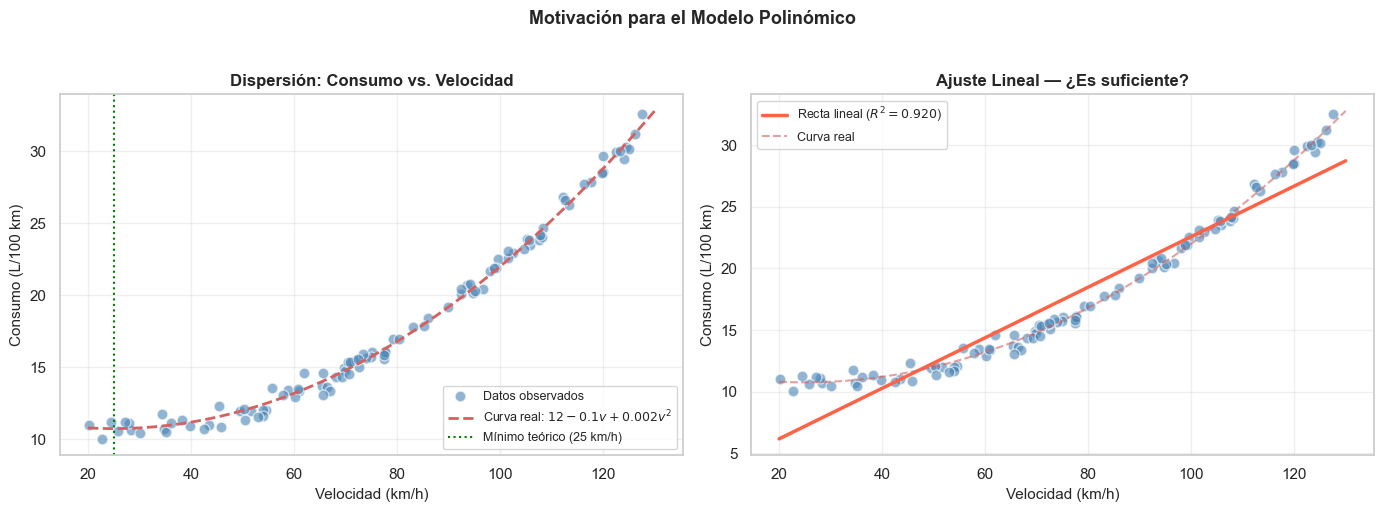

Modelo lineal: R² = 0.9196  →  No captura bien la curvatura


In [36]:
# ── Visualización exploratoria ─────────────────────────────────────────────
v_range = np.linspace(20, 130, 300)
y_true  = b0_real + b1_real * v_range + b2_real * v_range**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dispersión + curva poblacional
axes[0].scatter(df['velocidad'], df['consumo'],
                color='steelblue', alpha=0.6, edgecolors='white', s=60, label='Datos observados')
axes[0].plot(v_range, y_true, 'r--', linewidth=2,
             label=f'Curva real: $12 - 0.1v + 0.002v^2$')
axes[0].axvline(25, color='green', linestyle=':', linewidth=1.5, label='Mínimo teórico (25 km/h)')
axes[0].set_xlabel('Velocidad (km/h)', fontsize=11)
axes[0].set_ylabel('Consumo (L/100 km)', fontsize=11)
axes[0].set_title('Dispersión: Consumo vs. Velocidad', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Qué ocurre si ajustamos una recta (modelo incorrecto)
X_lin  = sm.add_constant(df['velocidad'])
m_lin  = sm.OLS(df['consumo'], X_lin).fit()
axes[1].scatter(df['velocidad'], df['consumo'],
                color='steelblue', alpha=0.6, edgecolors='white', s=60)
axes[1].plot(v_range,
             m_lin.params['const'] + m_lin.params['velocidad'] * v_range,
             'tomato', linewidth=2.5, label=f'Recta lineal ($R^2={m_lin.rsquared:.3f}$)')
axes[1].plot(v_range, y_true, 'r--', linewidth=1.5, alpha=0.6, label='Curva real')
axes[1].set_xlabel('Velocidad (km/h)', fontsize=11)
axes[1].set_ylabel('Consumo (L/100 km)', fontsize=11)
axes[1].set_title('Ajuste Lineal — ¿Es suficiente?', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Motivación para el Modelo Polinómico', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Modelo lineal: R² = {m_lin.rsquared:.4f}  →  No captura bien la curvatura")

## 1.3 Ajuste del Modelo Polinómico con MCO

### Construcción de la matriz de diseño

Para un modelo cuadrático ($p=2$), la matriz de diseño es:

$$X = \begin{pmatrix} 1 & x_1 & x_1^2 \\ 1 & x_2 & x_2^2 \\ \vdots & \vdots & \vdots \\ 1 & x_n & x_n^2 \end{pmatrix}$$

Los estimadores MCO se obtienen como siempre:
$$\hat{\boldsymbol{\beta}} = (X^\top X)^{-1} X^\top \mathbf{y}$$

### Centrado de la variable predictora (recomendado)

Para reducir la **multicolinealidad** entre $X$ y $X^2$ (que suelen estar muy correlacionadas), es conveniente centrar:

$$\tilde{X} = X - \bar{X}$$

Esto no cambia las predicciones del modelo, pero mejora la estabilidad numérica y facilita la interpretación del intercepto.

In [37]:
# ── Ajuste del modelo cuadrático con statsmodels ───────────────────────────
# Creamos las columnas: velocidad y velocidad²
v      = df['velocidad'].values
v_mean = v.mean()

df['velocidad_c']  = v - v_mean          # centrada
df['velocidad_c2'] = (v - v_mean) ** 2   # cuadrática centrada

X_quad = sm.add_constant(df[['velocidad_c', 'velocidad_c2']])
m_quad = sm.OLS(df['consumo'], X_quad).fit()

print(m_quad.summary())
print(f"\n  Media de velocidad usada para centrar: {v_mean:.2f} km/h")

                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     9279.
Date:                Wed, 27 May 2026   Prob (F-statistic):          1.67e-111
Time:                        11:51:56   Log-Likelihood:                -62.136
No. Observations:                 100   AIC:                             130.3
Df Residuals:                      97   BIC:                             138.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           16.1081      0.064    250.137   

## 1.4 Interpretación de los Coeficientes

Con el modelo centrado $\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 (X - \bar{X}) + \hat{\beta}_2 (X - \bar{X})^2$:

| Coeficiente | Interpretación |
|-------------|---------------|
| $\hat{\beta}_0$ | Consumo estimado cuando la velocidad es igual a la **media** $\bar{X}$ |
| $\hat{\beta}_1$ | Cambio en el consumo por km/h adicional, **evaluado en la media** |
| $\hat{\beta}_2$ | Controla la **curvatura**: positivo → parábola ∪ (mínimo); negativo → parábola ∩ (máximo) |

### Punto óptimo (vértice de la parábola)

El valor de $X$ que minimiza (o maximiza) $\hat{Y}$ se obtiene derivando e igualando a cero:

$$\frac{d\hat{Y}}{dX} = \hat{\beta}_1 + 2\hat{\beta}_2(X - \bar{X}) = 0 \implies X^* = \bar{X} - \frac{\hat{\beta}_1}{2\hat{\beta}_2}$$

> Si $\hat{\beta}_2 > 0$ → **mínimo** (parábola abierta hacia arriba)  
> Si $\hat{\beta}_2 < 0$ → **máximo** (parábola abierta hacia abajo)

  Interpretación del Modelo Cuadrático Ajustado
  β̂₀ = 16.1081
    → Consumo estimado a v = 76.7 km/h (media): 16.11 L/100km

  β̂₁ = 0.2083
    → En la media, por cada km/h adicional el consumo
      cambia en 0.2083 L/100km

  β̂₂ = 0.0020 > 0 → Parábola ∪ (existe un mínimo)

  Velocidad óptima estimada: v* = 24.5 km/h
  Velocidad óptima real:     v* = 25.0 km/h
  Consumo mínimo estimado:   10.67 L/100km

  R² = 0.9948  |  R² ajustado = 0.9947


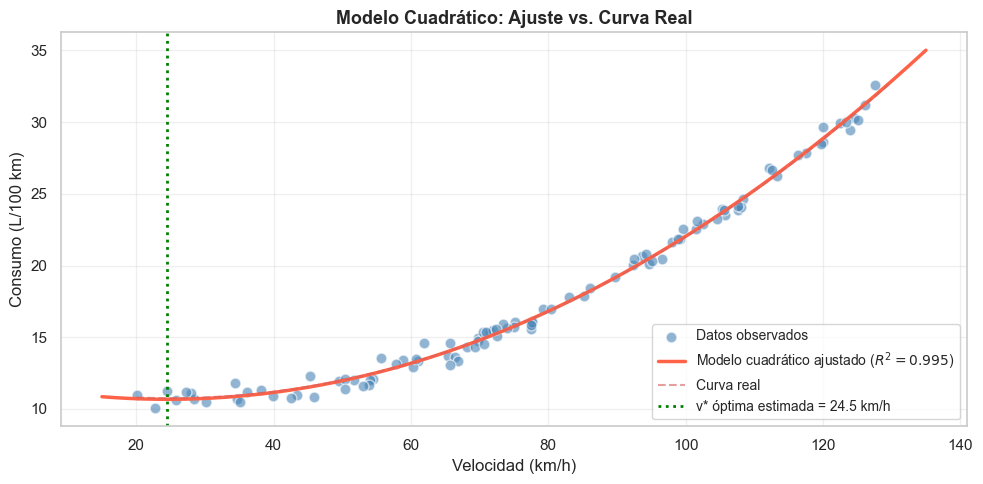

In [38]:
# ── Interpretación del modelo ajustado ────────────────────────────────────
b0_est = m_quad.params['const']
b1_est = m_quad.params['velocidad_c']
b2_est = m_quad.params['velocidad_c2']

v_optimo = v_mean - b1_est / (2 * b2_est)
consumo_optimo = b0_est + b1_est * (v_optimo - v_mean) + b2_est * (v_optimo - v_mean)**2

print("=" * 58)
print("  Interpretación del Modelo Cuadrático Ajustado")
print("=" * 58)
print(f"  β̂₀ = {b0_est:.4f}")
print(f"    → Consumo estimado a v = {v_mean:.1f} km/h (media): {b0_est:.2f} L/100km")
print()
print(f"  β̂₁ = {b1_est:.4f}")
print(f"    → En la media, por cada km/h adicional el consumo")
print(f"      cambia en {b1_est:.4f} L/100km")
print()
print(f"  β̂₂ = {b2_est:.4f} > 0 → Parábola ∪ (existe un mínimo)")
print()
print(f"  Velocidad óptima estimada: v* = {v_optimo:.1f} km/h")
print(f"  Velocidad óptima real:     v* = 25.0 km/h")
print(f"  Consumo mínimo estimado:   {consumo_optimo:.2f} L/100km")
print()
print(f"  R² = {m_quad.rsquared:.4f}  |  R² ajustado = {m_quad.rsquared_adj:.4f}")

# Visualización del ajuste
v_plot = np.linspace(15, 135, 300)
y_quad_pred = b0_est + b1_est*(v_plot - v_mean) + b2_est*(v_plot - v_mean)**2

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['velocidad'], df['consumo'],
           color='steelblue', alpha=0.6, edgecolors='white', s=60, label='Datos observados')
ax.plot(v_plot, y_quad_pred, 'tomato', linewidth=2.5,
        label=f'Modelo cuadrático ajustado ($R^2={m_quad.rsquared:.3f}$)')
ax.plot(v_range, y_true, 'r--', linewidth=1.5, alpha=0.6, label='Curva real')
ax.axvline(v_optimo, color='green', linestyle=':', linewidth=2,
           label=f'v* óptima estimada = {v_optimo:.1f} km/h')
ax.set_xlabel('Velocidad (km/h)', fontsize=12)
ax.set_ylabel('Consumo (L/100 km)', fontsize=12)
ax.set_title('Modelo Cuadrático: Ajuste vs. Curva Real', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 1.5 Selección del Grado del Polinomio: Underfitting vs. Overfitting

Un problema fundamental en los modelos polinómicos es **elegir el grado $p$**:

- **Underfitting** ($p$ demasiado bajo): el modelo no captura la estructura real → alto sesgo
- **Overfitting** ($p$ demasiado alto): el modelo memoriza el ruido → alta varianza, mala generalización

### Criterios para seleccionar $p$

| Criterio | Descripción | Penaliza complejidad |
|---------|-------------|---------------------|
| **$R^2$ ajustado** | Solo sube si el predictor agrega información real | Sí |
| **AIC** (Akaike) | $-2\ln L + 2k$ — menor es mejor | Sí |
| **BIC** (Bayesian) | $-2\ln L + k\ln n$ — más estricto que AIC | Sí (más) |
| **Validación cruzada** | Error de predicción en datos no vistos | Implícitamente |
| **Prueba F parcial** | ¿Agregar el término de grado $p$ mejora significativamente? | Con $\alpha$ |

### Principio de parsimonia

> El modelo más simple que explique adecuadamente los datos es preferible al más complejo.

In [39]:
# ── Comparación de modelos de grado 1 a 7 ─────────────────────────────────
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X_1d = df['velocidad'].values.reshape(-1, 1)
y    = df['consumo'].values

grados   = range(1, 8)
metricas = []

for p in grados:
    pf    = PolynomialFeatures(degree=p, include_bias=False)
    X_p   = pf.fit_transform(X_1d)
    X_p_c = sm.add_constant(X_p)
    m_p   = sm.OLS(y, X_p_c).fit()

    # R² ajustado, AIC, BIC
    r2_adj = m_p.rsquared_adj
    aic    = m_p.aic
    bic    = m_p.bic

    # CV-MSE con scikit-learn (5 folds)
    lr   = LinearRegression()
    cv_scores = cross_val_score(lr, X_p, y, cv=5,
                                scoring='neg_mean_squared_error')
    cv_mse = -cv_scores.mean()

    metricas.append({'Grado p': p, 'R² ajustado': round(r2_adj, 4),
                     'AIC': round(aic, 2), 'BIC': round(bic, 2),
                     'CV-MSE': round(cv_mse, 4)})

df_met = pd.DataFrame(metricas)
print(df_met.to_string(index=False))

# Marcar el mejor por cada criterio
print(f"\n→ Mejor R² ajustado : grado {df_met.loc[df_met['R² ajustado'].idxmax(), 'Grado p']}")
print(f"→ Menor AIC         : grado {df_met.loc[df_met['AIC'].idxmin(), 'Grado p']}")
print(f"→ Menor BIC         : grado {df_met.loc[df_met['BIC'].idxmin(), 'Grado p']}")
print(f"→ Menor CV-MSE      : grado {df_met.loc[df_met['CV-MSE'].idxmin(), 'Grado p']}")

 Grado p  R² ajustado    AIC    BIC  CV-MSE
       1       0.9188 402.13 407.34  3.3243
       2       0.9947 130.27 138.09  0.2165
       3       0.9948 129.91 140.33  0.2208
       4       0.9947 131.83 144.86  0.2249
       5       0.9947 133.33 148.96  0.2319
       6       0.9946 135.23 153.46  0.2440
       7       0.9947 132.89 148.52  0.2416

→ Mejor R² ajustado : grado 3
→ Menor AIC         : grado 3
→ Menor BIC         : grado 2
→ Menor CV-MSE      : grado 2


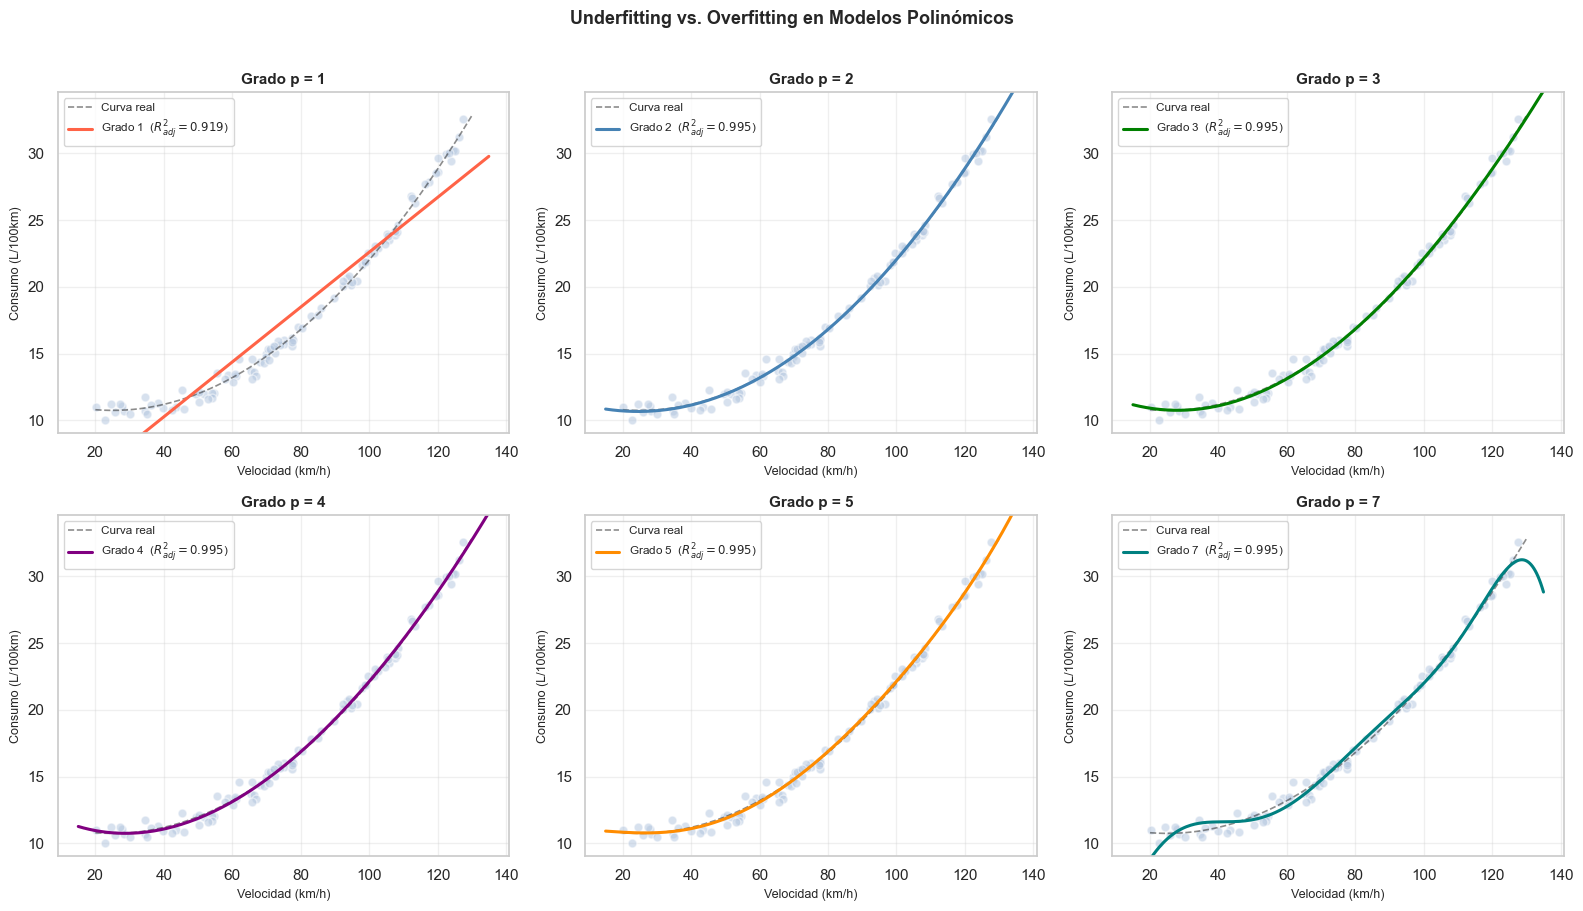

In [40]:
# ── Visualización: curvas ajustadas para distintos grados ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colores = ['tomato', 'steelblue', 'green', 'purple', 'darkorange', 'teal']
v_plot  = np.linspace(15, 135, 300).reshape(-1, 1)

for idx, p in enumerate([1, 2, 3, 4, 5, 7]):
    ax = axes[idx]
    ax.scatter(df['velocidad'], df['consumo'],
               color='lightsteelblue', alpha=0.5, s=40, edgecolors='white')
    ax.plot(v_range, y_true, 'k--', linewidth=1.2, alpha=0.5, label='Curva real')

    pf   = PolynomialFeatures(degree=p, include_bias=True)
    X_p  = pf.fit_transform(X_1d)
    lr   = LinearRegression(fit_intercept=False).fit(X_p, y)
    y_pr = lr.predict(pf.transform(v_plot))

    # R² ajustado
    X_p_c = sm.add_constant(PolynomialFeatures(degree=p, include_bias=False).fit_transform(X_1d))
    m_p   = sm.OLS(y, X_p_c).fit()

    ax.plot(v_plot, y_pr, color=colores[idx], linewidth=2.2,
            label=f'Grado {p}  ($R^2_{{adj}}={m_p.rsquared_adj:.3f}$)')
    ax.set_title(f'Grado p = {p}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Velocidad (km/h)', fontsize=9)
    ax.set_ylabel('Consumo (L/100km)', fontsize=9)
    ax.legend(fontsize=8.5)
    ax.set_ylim(df['consumo'].min() - 1, df['consumo'].max() + 2)

plt.suptitle('Underfitting vs. Overfitting en Modelos Polinómicos', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

c:\Users\natalia.acevedop\Documents\GitHub\MisCursos\.venv\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2823529411764706, 0.47058823529411764, 0.8156862745098039, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


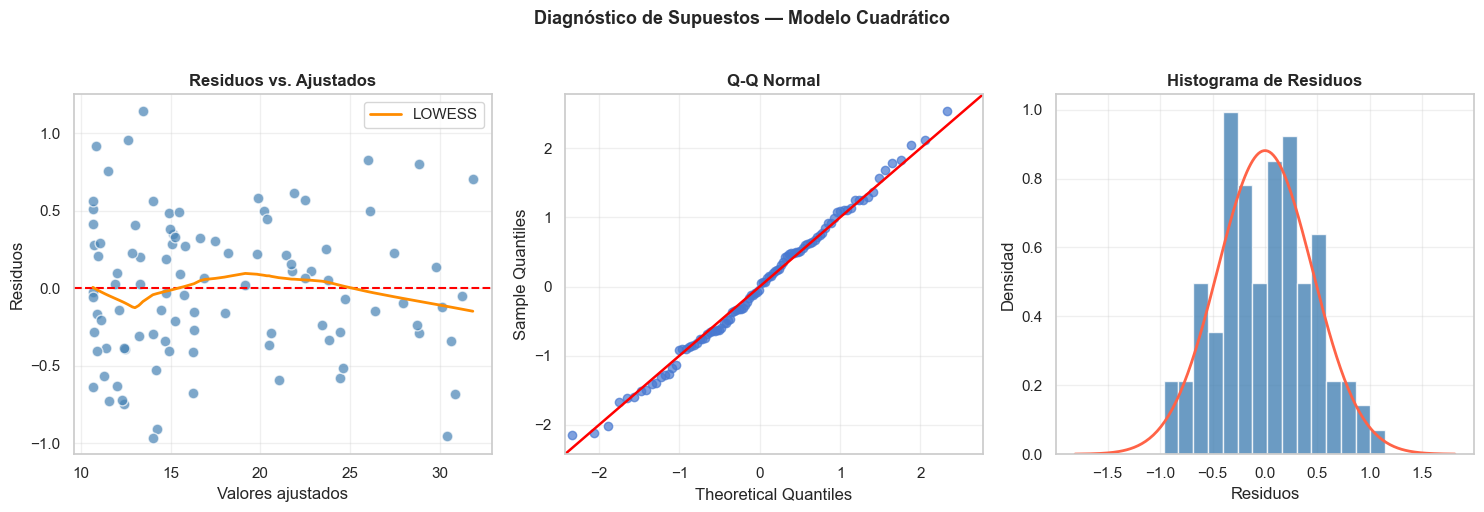

Shapiro-Wilk   : W = 0.9928,  p = 0.8750  →  ✓ Normalidad
Durbin-Watson  : DW = 1.8523         →  ✓ Independencia
Breusch-Pagan  : BP = 0.7676, p = 0.6813  →  ✓ Homocedasticidad


In [41]:
# ── Diagnóstico de supuestos del modelo cuadrático elegido ────────────────
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.gofplots import ProbPlot

fitted_quad = m_quad.fittedvalues
resid_quad  = m_quad.resid
infl        = m_quad.get_influence()
resid_std   = infl.resid_studentized_internal

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Residuos vs. ajustados
axes[0].scatter(fitted_quad, resid_quad, color='steelblue', alpha=0.7,
                edgecolors='white', s=60)
axes[0].axhline(0, color='red', linestyle='--')
lw = sm.nonparametric.lowess(resid_quad, fitted_quad, frac=0.5)
axes[0].plot(lw[:, 0], lw[:, 1], color='darkorange', linewidth=2, label='LOWESS')
axes[0].set_xlabel('Valores ajustados'); axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs. Ajustados', fontweight='bold'); axes[0].legend()

# Q-Q plot
pp = ProbPlot(resid_quad, fit=True)
pp.qqplot(ax=axes[1], line='45', alpha=0.7, color='steelblue')
axes[1].get_lines()[1].set(color='red', linewidth=1.8)
axes[1].set_title('Q-Q Normal', fontweight='bold')

# Histograma de residuos
axes[2].hist(resid_quad, bins=15, color='steelblue', edgecolor='white', alpha=0.8, density=True)
mu, sd = resid_quad.mean(), resid_quad.std()
xn = np.linspace(mu - 4*sd, mu + 4*sd, 200)
axes[2].plot(xn, stats.norm.pdf(xn, mu, sd), 'tomato', linewidth=2)
axes[2].set_xlabel('Residuos'); axes[2].set_ylabel('Densidad')
axes[2].set_title('Histograma de Residuos', fontweight='bold')

plt.suptitle('Diagnóstico de Supuestos — Modelo Cuadrático', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Pruebas
sw_stat, sw_p = shapiro(resid_quad)
dw_val = durbin_watson(resid_quad)
bp_stat, bp_p, _, _ = het_breuschpagan(resid_quad, X_quad)

print(f"Shapiro-Wilk   : W = {sw_stat:.4f},  p = {sw_p:.4f}  →  {'✓ Normalidad' if sw_p > 0.05 else '✗ No normalidad'}")
print(f"Durbin-Watson  : DW = {dw_val:.4f}         →  {'✓ Independencia' if 1.5 <= dw_val <= 2.5 else '✗ Autocorrelación'}")
print(f"Breusch-Pagan  : BP = {bp_stat:.4f}, p = {bp_p:.4f}  →  {'✓ Homocedasticidad' if bp_p > 0.05 else '✗ Heterocedasticidad'}")

# PARTE 2 — Modelos Logarítmicos

## 2.1 Definición y Tipos de Transformaciones

Los **modelos logarítmicos** aplican la transformación $\ln(\cdot)$ a $Y$, a $X$, o a ambas, para linealizar relaciones no lineales y para trabajar con datos que presentan:

- Crecimientos o decrecimientos a tasa decreciente
- Relaciones multiplicativas
- Variables con distribución asimétrica positiva (ingresos, precios, poblaciones)
- Heterocedasticidad en los datos originales

### Los cuatro modelos principales

| Modelo | Ecuación | Linealización | Interpretación de $\beta_1$ |
|--------|---------|--------------|----------------------------|
| **Log-Lin** (Semilog) | $\ln(Y) = \beta_0 + \beta_1 X + \varepsilon$ | — | Un aumento de 1 unidad en $X$ → $Y$ cambia un $100 \cdot \beta_1$% |
| **Lin-Log** | $Y = \beta_0 + \beta_1 \ln(X) + \varepsilon$ | — | Un aumento del 1% en $X$ → $Y$ cambia en $\beta_1/100$ unidades |
| **Log-Log** (Doble log) | $\ln(Y) = \beta_0 + \beta_1 \ln(X) + \varepsilon$ | — | $\beta_1$ es la **elasticidad**: un 1% de aumento en $X$ → $Y$ cambia un $\beta_1$% |
| **Log-Log cuadrático** | $\ln(Y) = \beta_0 + \beta_1 \ln(X) + \beta_2 [\ln(X)]^2 + \varepsilon$ | — | Elasticidad variable con $X$ |

### Condición de aplicabilidad

Todos los logaritmos requieren que las variables sean **estrictamente positivas** ($X > 0$ y $Y > 0$). Si hay ceros o negativos, se puede usar $\ln(X+1)$ o una transformación alternativa.


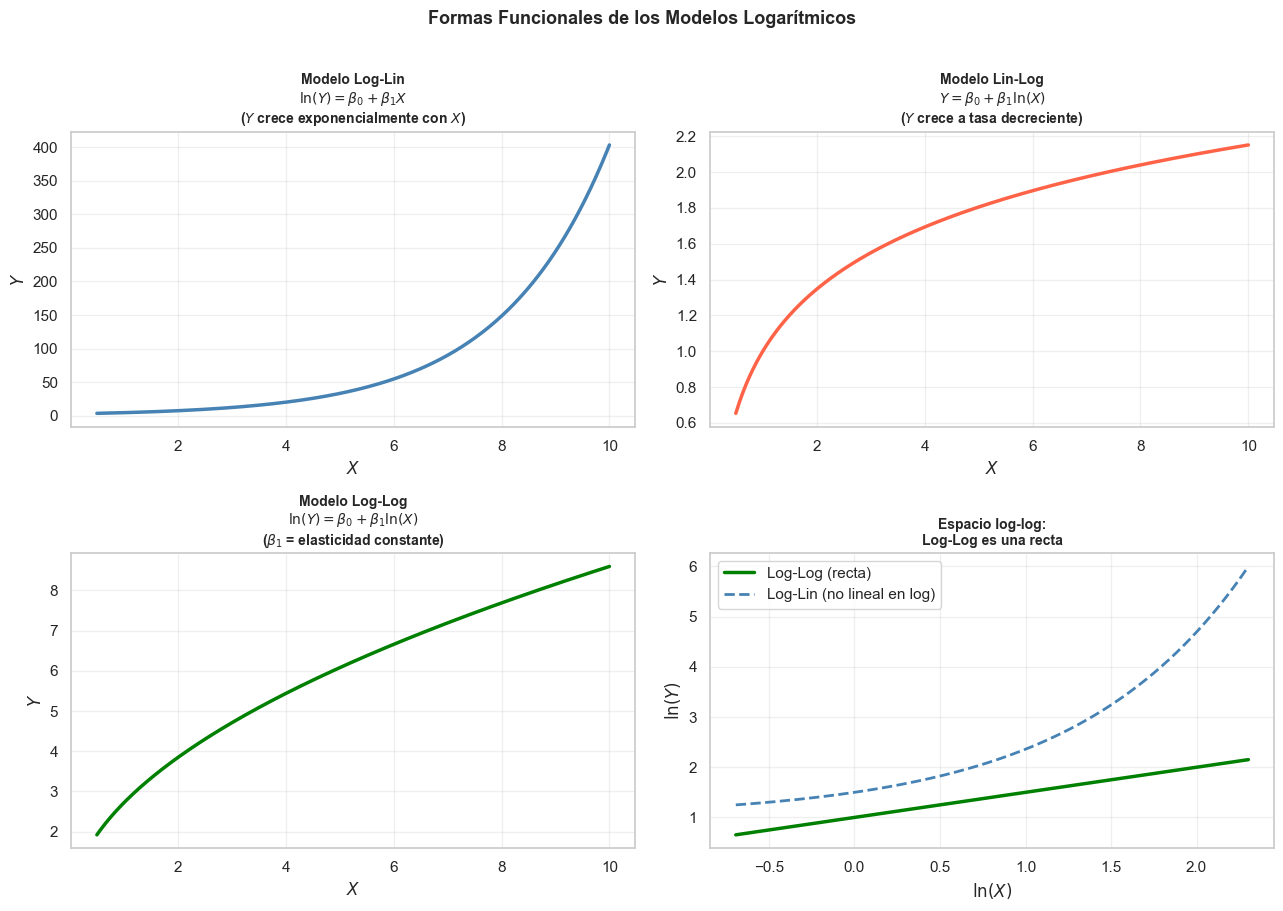

In [42]:
# ── Visualización de las formas funcionales logarítmicas ──────────────────
x_demo = np.linspace(0.5, 10, 300)
b0_d, b1_d = 1.0, 0.5

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) Log-Lin: ln(Y) = b0 + b1*X  →  Y = exp(b0 + b1*X)
axes[0,0].plot(x_demo, np.exp(b0_d + b1_d * x_demo), 'steelblue', linewidth=2.5)
axes[0,0].set_title('Modelo Log-Lin\n$\\ln(Y) = \\beta_0 + \\beta_1 X$\n($Y$ crece exponencialmente con $X$)',
                    fontsize=10, fontweight='bold')
axes[0,0].set_xlabel('$X$'); axes[0,0].set_ylabel('$Y$')

# 2) Lin-Log: Y = b0 + b1*ln(X)
axes[0,1].plot(x_demo, b0_d + b1_d * np.log(x_demo), 'tomato', linewidth=2.5)
axes[0,1].set_title('Modelo Lin-Log\n$Y = \\beta_0 + \\beta_1 \\ln(X)$\n($Y$ crece a tasa decreciente)',
                    fontsize=10, fontweight='bold')
axes[0,1].set_xlabel('$X$'); axes[0,1].set_ylabel('$Y$')

# 3) Log-Log: ln(Y) = b0 + b1*ln(X)  →  Y = exp(b0) * X^b1
axes[1,0].plot(x_demo, np.exp(b0_d) * x_demo**b1_d, 'green', linewidth=2.5)
axes[1,0].set_title('Modelo Log-Log\n$\\ln(Y) = \\beta_0 + \\beta_1 \\ln(X)$\n($\\beta_1$ = elasticidad constante)',
                    fontsize=10, fontweight='bold')
axes[1,0].set_xlabel('$X$'); axes[1,0].set_ylabel('$Y$')

# 4) Comparación en escala log-log
axes[1,1].plot(np.log(x_demo), np.log(np.exp(b0_d) * x_demo**b1_d),
               'green', linewidth=2.5, label='Log-Log (recta)')
axes[1,1].plot(np.log(x_demo), b0_d + b1_d * x_demo,
               'steelblue', linewidth=2, linestyle='--', label='Log-Lin (no lineal en log)')
axes[1,1].set_title('Espacio log-log:\nLog-Log es una recta', fontsize=10, fontweight='bold')
axes[1,1].set_xlabel('$\\ln(X)$'); axes[1,1].set_ylabel('$\\ln(Y)$')
axes[1,1].legend()

plt.suptitle('Formas Funcionales de los Modelos Logarítmicos', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2.2 Ejemplo 1 — Modelo Log-Lin: Crecimiento Salarial

**Contexto**: El salario de una persona tiende a crecer a una **tasa porcentual aproximadamente constante** con los años de experiencia laboral (rendimientos decrecientes en el tiempo, pero crecimiento exponencial en el nivel).

**Modelo verdadero**:
$$\ln(\text{Salario}_i) = 7.5 + 0.08 \cdot \text{Experiencia}_i + \varepsilon_i$$

En términos de salario: $\text{Salario}_i = e^{7.5} \cdot e^{0.08 \cdot \text{Exp}_i}$

**Interpretación**: Por cada año adicional de experiencia, el salario aumenta aproximadamente un $8\%$ ($100 \times 0.08 = 8\%$).

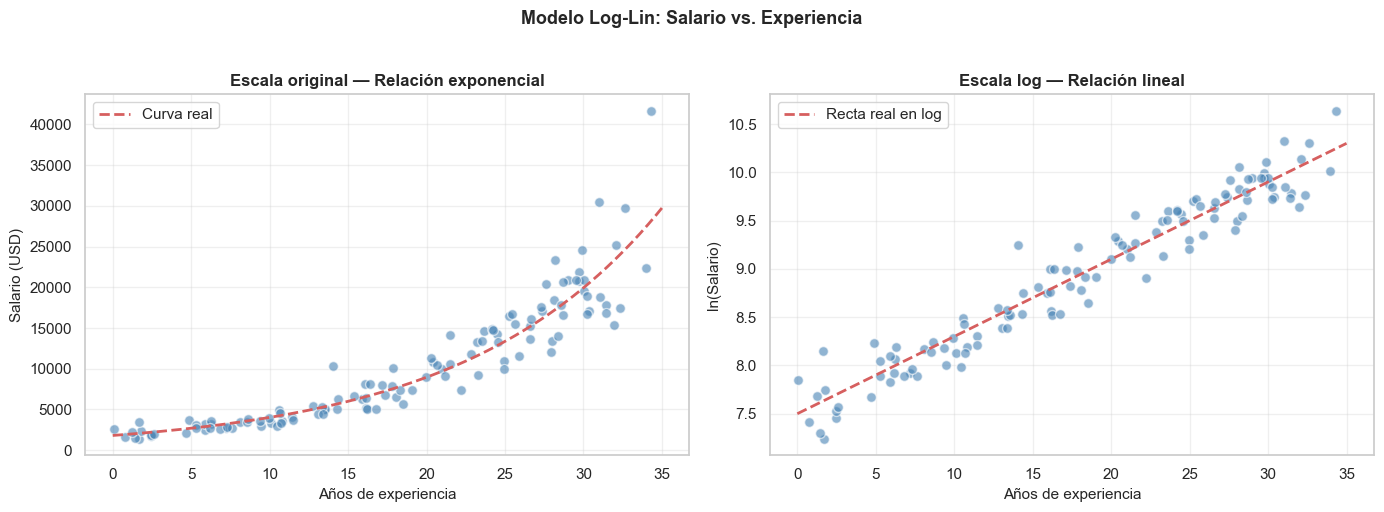

In [43]:
# ── Generación de datos Log-Lin ───────────────────────────────────────────
np.random.seed(21)
n_sal = 120

experiencia = np.random.uniform(0, 35, n_sal)
ln_salario  = 7.5 + 0.08 * experiencia + np.random.normal(0, 0.20, n_sal)
salario     = np.exp(ln_salario)

df_sal = pd.DataFrame({'experiencia': experiencia,
                       'salario': salario,
                       'ln_salario': ln_salario})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala original: relación exponencial
axes[0].scatter(df_sal['experiencia'], df_sal['salario'],
                color='steelblue', alpha=0.6, s=50, edgecolors='white')
exp_range = np.linspace(0, 35, 200)
axes[0].plot(exp_range, np.exp(7.5 + 0.08 * exp_range), 'r--', linewidth=2,
             label='Curva real')
axes[0].set_xlabel('Años de experiencia', fontsize=11)
axes[0].set_ylabel('Salario (USD)', fontsize=11)
axes[0].set_title('Escala original — Relación exponencial', fontsize=12, fontweight='bold')
axes[0].legend()

# Escala logarítmica: relación lineal
axes[1].scatter(df_sal['experiencia'], df_sal['ln_salario'],
                color='steelblue', alpha=0.6, s=50, edgecolors='white')
axes[1].plot(exp_range, 7.5 + 0.08 * exp_range, 'r--', linewidth=2,
             label='Recta real en log')
axes[1].set_xlabel('Años de experiencia', fontsize=11)
axes[1].set_ylabel('ln(Salario)', fontsize=11)
axes[1].set_title('Escala log — Relación lineal', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Modelo Log-Lin: Salario vs. Experiencia', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [44]:
# ── Ajuste e interpretación del modelo Log-Lin ────────────────────────────
X_sal = sm.add_constant(df_sal['experiencia'])
m_loglin = sm.OLS(df_sal['ln_salario'], X_sal).fit()

print(m_loglin.summary())

b0_ll = m_loglin.params['const']
b1_ll = m_loglin.params['experiencia']

print("\n" + "=" * 58)
print("  Interpretación del Modelo Log-Lin")
print("=" * 58)
print(f"  β̂₀ = {b0_ll:.4f}")
print(f"    → Salario estimado con 0 años de exp: ${np.exp(b0_ll):,.0f}")
print()
print(f"  β̂₁ = {b1_ll:.4f}")
print(f"    → Por cada año adicional de experiencia,")
print(f"      el salario aumenta aprox. {100*b1_ll:.1f}%")
print()
print(f"  Efecto exacto: e^{b1_ll:.4f} - 1 = {(np.exp(b1_ll)-1)*100:.2f}% por año")
print(f"\n  R² = {m_loglin.rsquared:.4f}")

                            OLS Regression Results                            
Dep. Variable:             ln_salario   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     1855.
Date:                Wed, 27 May 2026   Prob (F-statistic):           5.11e-74
Time:                        11:51:57   Log-Likelihood:                 24.269
No. Observations:                 120   AIC:                            -44.54
Df Residuals:                     118   BIC:                            -38.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           7.4603      0.039    191.033      

## 2.3 Ejemplo 2 — Modelo Log-Log: Elasticidad Precio-Demanda

**Contexto**: En economía, la **elasticidad precio** de la demanda mide cuánto varía (en %) la cantidad demandada ante un 1% de cambio en el precio. El modelo Log-Log es el estándar para estimarla.

**Modelo verdadero**:
$$\ln(\text{Demanda}_i) = 8 - 1.5 \cdot \ln(\text{Precio}_i) + \varepsilon_i$$

**Interpretación**: $\beta_1 = -1.5$ significa que un **aumento del 1% en el precio** genera una **caída del 1.5% en la demanda** (demanda elástica, $|\beta_1| > 1$).

En términos originales: $\text{Demanda} = e^8 \cdot \text{Precio}^{-1.5}$

C:\Users\natalia.acevedop\AppData\Local\Temp\ipykernel_19804\3366508595.py:38: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\natalia.acevedop\Documents\GitHub\MisCursos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


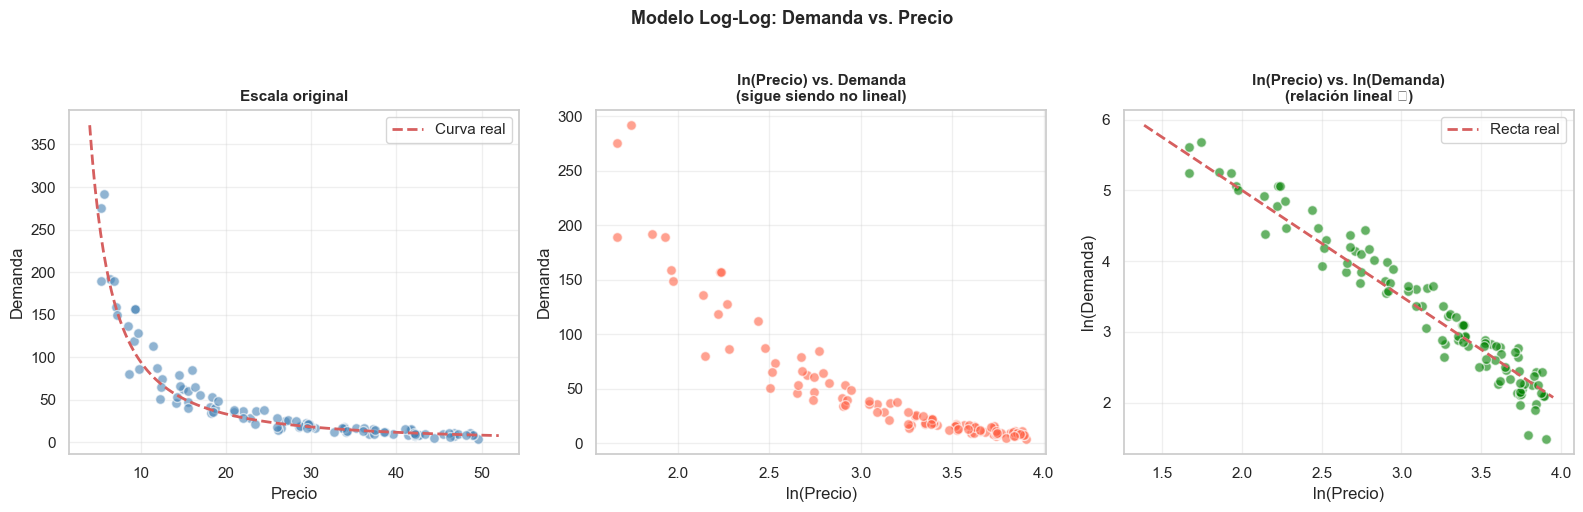

In [45]:
# ── Datos Log-Log: Demanda vs. Precio ─────────────────────────────────────
np.random.seed(99)
n_dem = 100

precio   = np.random.uniform(5, 50, n_dem)
ln_dem   = 8 - 1.5 * np.log(precio) + np.random.normal(0, 0.25, n_dem)
demanda  = np.exp(ln_dem)

df_dem = pd.DataFrame({'precio': precio, 'demanda': demanda,
                       'ln_precio': np.log(precio), 'ln_demanda': ln_dem})

p_range = np.linspace(4, 52, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Escala original: curva de demanda
axes[0].scatter(df_dem['precio'], df_dem['demanda'],
                color='steelblue', alpha=0.6, s=50, edgecolors='white')
axes[0].plot(p_range, np.exp(8) * p_range**(-1.5), 'r--', linewidth=2, label='Curva real')
axes[0].set_xlabel('Precio'); axes[0].set_ylabel('Demanda')
axes[0].set_title('Escala original', fontsize=11, fontweight='bold'); axes[0].legend()

# Escala ln(precio) vs demanda (Lin-Log)
axes[1].scatter(df_dem['ln_precio'], df_dem['demanda'],
                color='tomato', alpha=0.6, s=50, edgecolors='white')
axes[1].set_xlabel('ln(Precio)'); axes[1].set_ylabel('Demanda')
axes[1].set_title('ln(Precio) vs. Demanda\n(sigue siendo no lineal)', fontsize=11, fontweight='bold')

# Escala doble log: relación lineal
axes[2].scatter(df_dem['ln_precio'], df_dem['ln_demanda'],
                color='green', alpha=0.6, s=50, edgecolors='white')
axes[2].plot(np.log(p_range), 8 - 1.5 * np.log(p_range), 'r--', linewidth=2, label='Recta real')
axes[2].set_xlabel('ln(Precio)'); axes[2].set_ylabel('ln(Demanda)')
axes[2].set_title('ln(Precio) vs. ln(Demanda)\n(relación lineal ✓)', fontsize=11, fontweight='bold')
axes[2].legend()

plt.suptitle('Modelo Log-Log: Demanda vs. Precio', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [46]:
# ── Ajuste e interpretación del modelo Log-Log ────────────────────────────
X_dem = sm.add_constant(df_dem['ln_precio'])
m_loglog = sm.OLS(df_dem['ln_demanda'], X_dem).fit()

print(m_loglog.summary())

b0_ll2 = m_loglog.params['const']
b1_ll2 = m_loglog.params['ln_precio']

print("\n" + "=" * 60)
print("  Interpretación del Modelo Log-Log (Elasticidad)")
print("=" * 60)
print(f"  β̂₀ = {b0_ll2:.4f}")
print(f"    → Constante de escala (no interpretación directa)")
print()
print(f"  β̂₁ = {b1_ll2:.4f}  ← ELASTICIDAD PRECIO-DEMANDA")
print(f"    → Un aumento del 1% en el precio genera un")
print(f"      cambio del {b1_ll2:.2f}% en la demanda")
print()
if abs(b1_ll2) > 1:
    print(f"    → |β̂₁| = {abs(b1_ll2):.2f} > 1: Demanda ELÁSTICA")
    print(f"       (la demanda es muy sensible al precio)")
else:
    print(f"    → |β̂₁| = {abs(b1_ll2):.2f} < 1: Demanda INELÁSTICA")
    print(f"       (la demanda no responde mucho al precio)")
print()
print(f"  R² = {m_loglog.rsquared:.4f}")

                            OLS Regression Results                            
Dep. Variable:             ln_demanda   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     1699.
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.02e-63
Time:                        11:51:57   Log-Likelihood:                 3.3375
No. Observations:                 100   AIC:                            -2.675
Df Residuals:                      98   BIC:                             2.535
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3606      0.125     66.862      0.0

## 2.4 Ejemplo 3 — Modelo Lin-Log: Rendimiento de Cultivos

**Contexto**: La producción de un cultivo en función de la cantidad de fertilizante aplicado (kg/ha) presenta **rendimientos decrecientes**: cada kg adicional agrega menos producción que el anterior.

**Modelo verdadero**:
$$\text{Producción}_i = -5 + 12 \cdot \ln(\text{Fertilizante}_i) + \varepsilon_i$$

**Interpretación**: $\beta_1 = 12$ significa que un **aumento del 1% en la cantidad de fertilizante** agrega $12/100 = 0.12$ ton/ha a la producción.

C:\Users\natalia.acevedop\AppData\Local\Temp\ipykernel_19804\3027303755.py:32: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\natalia.acevedop\Documents\GitHub\MisCursos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


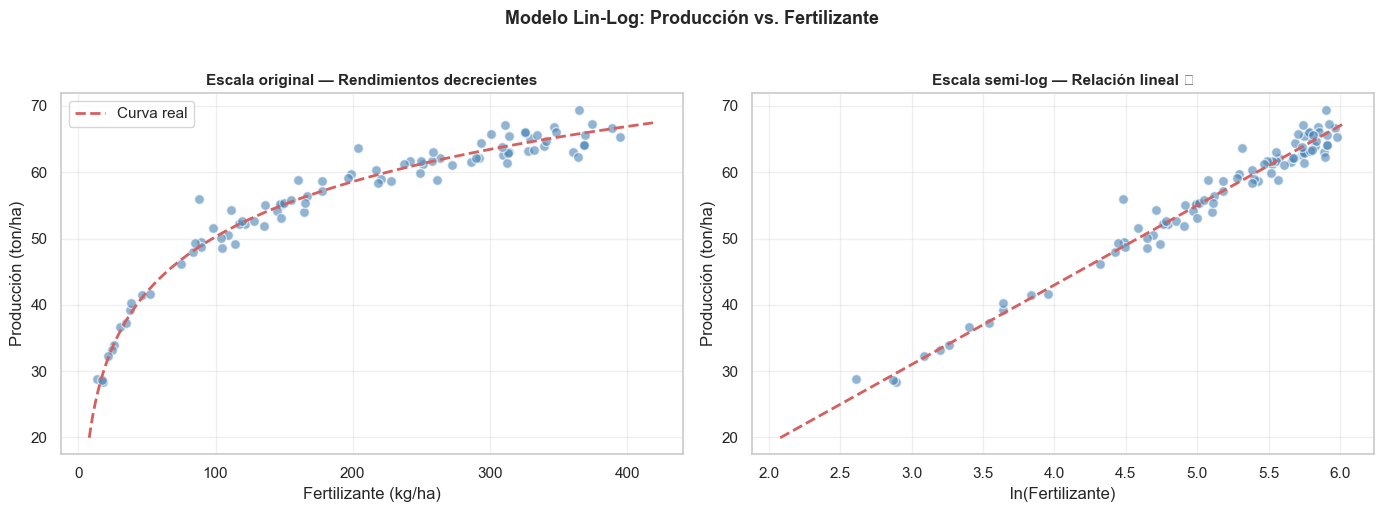

β̂₀ = -3.9300
β̂₁ = 11.8003

Interpretación:
  Un aumento del 1% en fertilizante agrega 0.1180 ton/ha
  Un aumento del 10% en fertilizante agrega 1.125 ton/ha
  Un aumento del 100% (duplicar) agrega 8.179 ton/ha

R² = 0.9721


In [47]:
# ── Datos Lin-Log: Producción vs. Fertilizante ────────────────────────────
np.random.seed(55)
n_fer = 90

fertilizante = np.random.uniform(10, 400, n_fer)
produccion   = -5 + 12 * np.log(fertilizante) + np.random.normal(0, 1.5, n_fer)

df_fer = pd.DataFrame({'fertilizante': fertilizante,
                       'produccion': produccion,
                       'ln_fertilizante': np.log(fertilizante)})

f_range = np.linspace(8, 420, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala original: relación logarítmica
axes[0].scatter(df_fer['fertilizante'], df_fer['produccion'],
                color='steelblue', alpha=0.6, s=50, edgecolors='white')
axes[0].plot(f_range, -5 + 12 * np.log(f_range), 'r--', linewidth=2, label='Curva real')
axes[0].set_xlabel('Fertilizante (kg/ha)'); axes[0].set_ylabel('Producción (ton/ha)')
axes[0].set_title('Escala original — Rendimientos decrecientes', fontsize=11, fontweight='bold')
axes[0].legend()

# Escala semi-log: relación lineal
axes[1].scatter(df_fer['ln_fertilizante'], df_fer['produccion'],
                color='steelblue', alpha=0.6, s=50, edgecolors='white')
axes[1].plot(np.log(f_range), -5 + 12 * np.log(f_range), 'r--', linewidth=2)
axes[1].set_xlabel('ln(Fertilizante)'); axes[1].set_ylabel('Producción (ton/ha)')
axes[1].set_title('Escala semi-log — Relación lineal ✓', fontsize=11, fontweight='bold')

plt.suptitle('Modelo Lin-Log: Producción vs. Fertilizante', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Ajuste
X_fer = sm.add_constant(df_fer['ln_fertilizante'])
m_linlog = sm.OLS(df_fer['produccion'], X_fer).fit()

b0_lilo = m_linlog.params['const']
b1_lilo = m_linlog.params['ln_fertilizante']

print(f"β̂₀ = {b0_lilo:.4f}")
print(f"β̂₁ = {b1_lilo:.4f}")
print(f"\nInterpretación:")
print(f"  Un aumento del 1% en fertilizante agrega {b1_lilo/100:.4f} ton/ha")
print(f"  Un aumento del 10% en fertilizante agrega {b1_lilo * np.log(1.10):.3f} ton/ha")
print(f"  Un aumento del 100% (duplicar) agrega {b1_lilo * np.log(2):.3f} ton/ha")
print(f"\nR² = {m_linlog.rsquared:.4f}")

## 3. Comparación de los Cuatro Modelos con un Mismo Dataset

Para ilustrar cómo elegir entre los modelos, ajustaremos los cuatro tipos al mismo conjunto de datos y compararemos sus métricas.

> **Nota sobre $R^2$ entre modelos con distinta variable dependiente**: No es válido comparar directamente el $R^2$ de un modelo donde $Y$ es la variable dependiente con el de uno donde $\ln(Y)$ es la dependiente, porque miden ajustes en espacios distintos. Para comparar, se transforma la predicción al espacio original y se calcula el $R^2$ sobre $Y$.


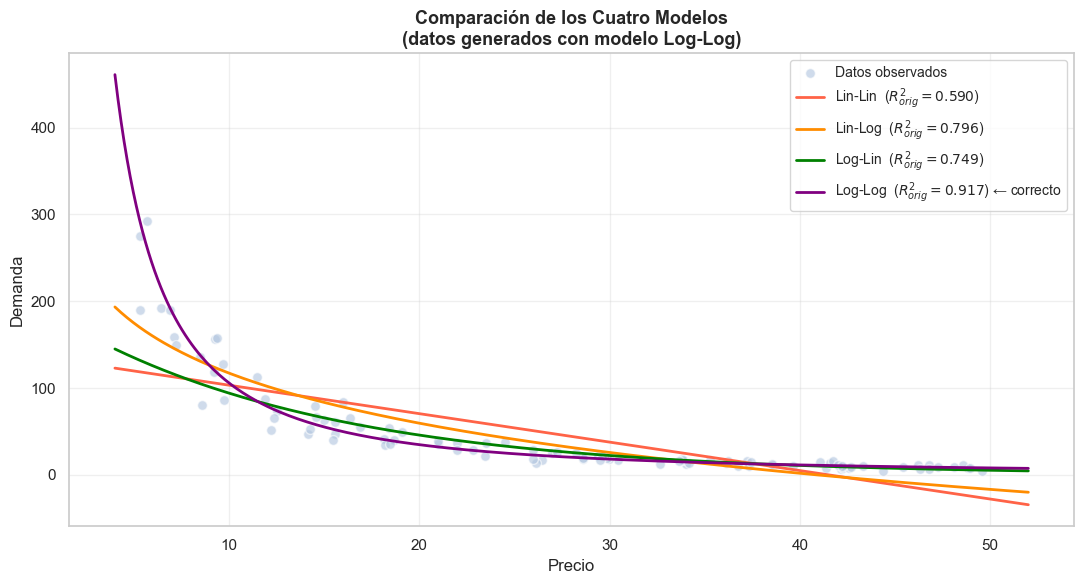

R² en escala original de Y:
  Lin-Lin : 0.5901
  Lin-Log : 0.7961
  Log-Lin : 0.7494
  Log-Log : 0.9174  ← mejor (modelo correcto)


In [48]:
# ── Comparación visual de los 4 modelos sobre datos Log-Log ───────────────
# Usamos el dataset de demanda (que es Log-Log por construcción)
X_orig = df_dem['precio'].values
Y_orig = df_dem['demanda'].values

p_plot  = np.linspace(4, 52, 300)

# Ajuste de cada modelo (X numpy array → params es ndarray, usar [i])
# 1) Lineal
m1 = sm.OLS(Y_orig, sm.add_constant(X_orig)).fit()
# 2) Lin-Log
m2 = sm.OLS(Y_orig, sm.add_constant(np.log(X_orig))).fit()
# 3) Log-Lin
m3 = sm.OLS(np.log(Y_orig), sm.add_constant(X_orig)).fit()
# 4) Log-Log
m4 = sm.OLS(np.log(Y_orig), sm.add_constant(np.log(X_orig))).fit()

# Predicciones en escala original
y1_pred = m1.params[0] + m1.params[1] * p_plot
y2_pred = m2.params[0] + m2.params[1] * np.log(p_plot)
y3_pred = np.exp(m3.params[0] + m3.params[1] * p_plot)
y4_pred = np.exp(m4.params[0] + m4.params[1] * np.log(p_plot))

# R² en escala original para todos
def r2_original(y_true, x_orig, model, tipo):
    if tipo == 'lin':
        yhat = model.params[0] + model.params[1] * x_orig
    elif tipo == 'linlog':
        yhat = model.params[0] + model.params[1] * np.log(x_orig)
    elif tipo == 'loglin':
        yhat = np.exp(model.params[0] + model.params[1] * x_orig)
    elif tipo == 'loglog':
        yhat = np.exp(model.params[0] + model.params[1] * np.log(x_orig))
    ss_res = np.sum((y_true - yhat)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / ss_tot

r2_m1 = r2_original(Y_orig, X_orig, m1, 'lin')
r2_m2 = r2_original(Y_orig, X_orig, m2, 'linlog')
r2_m3 = r2_original(Y_orig, X_orig, m3, 'loglin')
r2_m4 = r2_original(Y_orig, X_orig, m4, 'loglog')

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(X_orig, Y_orig, color='lightsteelblue', alpha=0.6, s=50,
           edgecolors='white', zorder=2, label='Datos observados')
ax.plot(p_plot, y1_pred, color='tomato',     linewidth=2, label=f'Lin-Lin  ($R^2_{{orig}}={r2_m1:.3f}$)')
ax.plot(p_plot, y2_pred, color='darkorange', linewidth=2, label=f'Lin-Log  ($R^2_{{orig}}={r2_m2:.3f}$)')
ax.plot(p_plot, y3_pred, color='green',      linewidth=2, label=f'Log-Lin  ($R^2_{{orig}}={r2_m3:.3f}$)')
ax.plot(p_plot, y4_pred, color='purple',     linewidth=2, label=f'Log-Log  ($R^2_{{orig}}={r2_m4:.3f}$) ← correcto')
ax.set_xlabel('Precio', fontsize=12)
ax.set_ylabel('Demanda', fontsize=12)
ax.set_title('Comparación de los Cuatro Modelos\n(datos generados con modelo Log-Log)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("R² en escala original de Y:")
print(f"  Lin-Lin : {r2_m1:.4f}")
print(f"  Lin-Log : {r2_m2:.4f}")
print(f"  Log-Lin : {r2_m3:.4f}")
print(f"  Log-Log : {r2_m4:.4f}  ← mejor (modelo correcto)")

## 4. Guía de Selección del Modelo

### ¿Cuándo usar cada modelo?

| Modelo | Señales visuales | Ejemplo típico |
|--------|-----------------|----------------|
| **Polinómico grado 2** | Forma de U o arco en la nube de puntos | Consumo vs. velocidad, dosis-respuesta |
| **Polinómico grado 3+** | Múltiples puntos de inflexión, curvas complejas | Ciclos de vida de productos |
| **Log-Lin** | $Y$ crece/decrece exponencialmente con $X$ | Crecimiento poblacional, precios en el tiempo |
| **Lin-Log** | $Y$ crece a tasa decreciente con $X$ | Rendimiento de aprendizaje, fertilizantes |
| **Log-Log** | Relación lineal en escala log-log; elasticidad constante | Demanda-precio, potencias en física |

### Checklist de decisión

1. **Grafica $Y$ vs. $X$** y **$\ln(Y)$ vs. $X$** y **$Y$ vs. $\ln(X)$** y **$\ln(Y)$ vs. $\ln(X)$**
2. Identifica cuál diagrama muestra la relación más lineal
3. Ajusta el modelo correspondiente
4. Verifica supuestos en el espacio transformado
5. Compara $R^2$ en escala original de $Y$ entre candidatos

### Advertencias importantes

- **No extrapolación**: los modelos polinómicos de alto grado son inestables fuera del rango de datos
- **Interpretación de $\beta_0$ en Log-Lin**: si $X \neq 0$ es posible, el intercepto no tiene interpretación directa  
- **Corrección de sesgo en anti-log**: al retransformar $\hat{Y} = e^{\hat{\ln Y}}$, la predicción está sesgada. El estimador corregido es $\hat{Y}_{corr} = e^{\hat{\ln Y} + s^2/2}$
- **Multicolinealidad en polinomios**: centrar la variable predictora antes de elevar al cuadrado reduce drásticamente la correlación entre $X$ y $X^2$


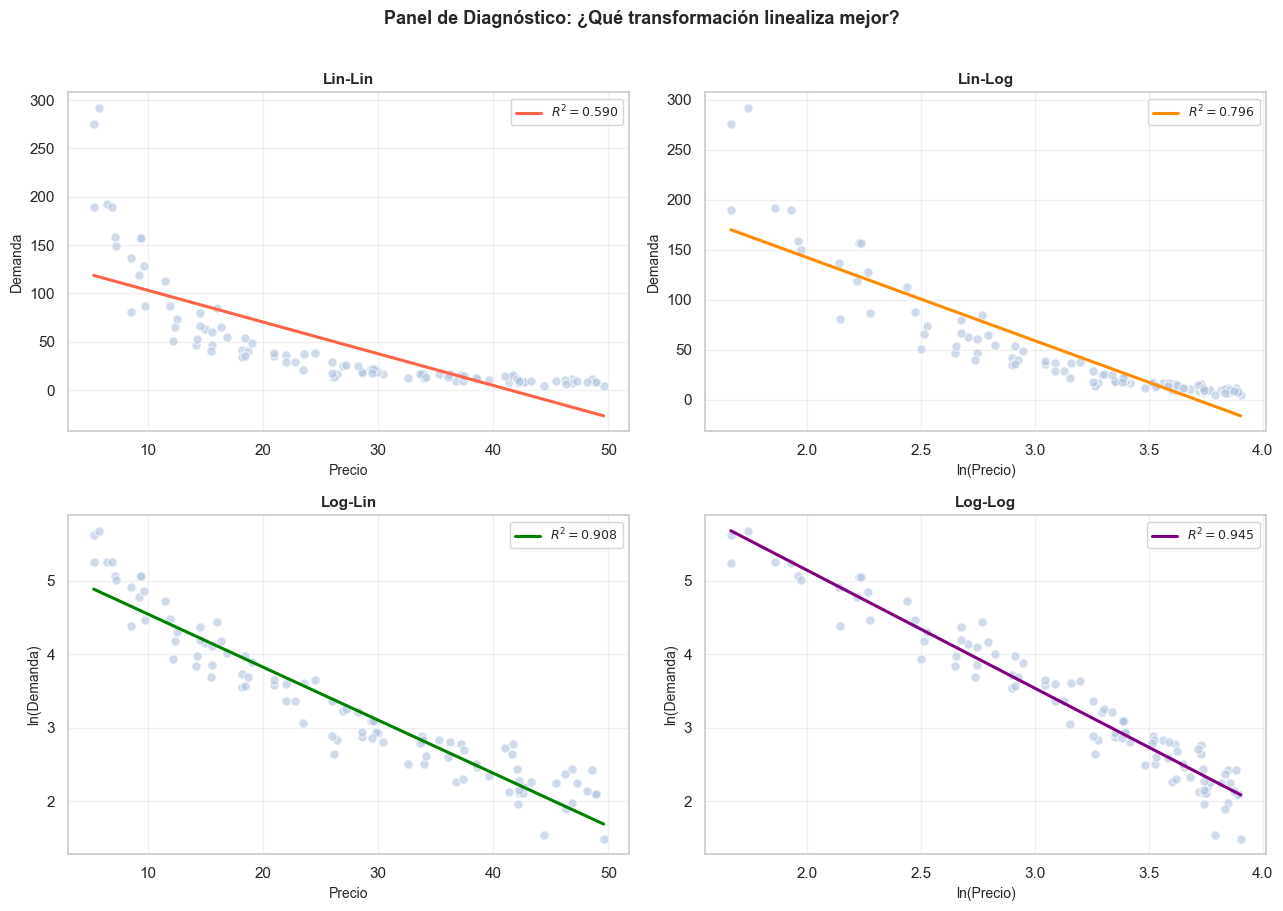

→ El gráfico con los puntos más alineados indica el modelo correcto.
  En este caso: Log-Log (panel inferior derecho) muestra la relación más lineal.


In [49]:
# ── Panel de los 4 diagramas de diagnóstico de transformación ─────────────
# Con los datos de demanda, se ilustra cómo encontrar el mejor modelo visualmente

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

configs = [
    (X_orig,          Y_orig,          'Precio',    'Demanda',    'Lin-Lin'),
    (np.log(X_orig),  Y_orig,          'ln(Precio)','Demanda',    'Lin-Log'),
    (X_orig,          np.log(Y_orig),  'Precio',    'ln(Demanda)','Log-Lin'),
    (np.log(X_orig),  np.log(Y_orig),  'ln(Precio)','ln(Demanda)','Log-Log'),
]
colores_diag = ['tomato', 'darkorange', 'green', 'purple']

for ax, (xd, yd, xl, yl, titulo), color in zip(axes.flatten(), configs, colores_diag):
    ax.scatter(xd, yd, color='lightsteelblue', alpha=0.6, s=45, edgecolors='white')
    # Línea de tendencia (X numpy array → params es ndarray, usar [i])
    X_tmp = sm.add_constant(xd)
    m_tmp = sm.OLS(yd, X_tmp).fit()
    x_s   = np.linspace(xd.min(), xd.max(), 200)
    ax.plot(x_s, m_tmp.params[0] + m_tmp.params[1] * x_s,
            color=color, linewidth=2.2,
            label=f'$R^2={m_tmp.rsquared:.3f}$')
    ax.set_xlabel(xl, fontsize=10); ax.set_ylabel(yl, fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Panel de Diagnóstico: ¿Qué transformación linealiza mejor?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("→ El gráfico con los puntos más alineados indica el modelo correcto.")
print("  En este caso: Log-Log (panel inferior derecho) muestra la relación más lineal.")

## 5. Resumen Final

### Modelos Polinómicos

| Aspecto | Detalle |
|---------|---------|
| **Ecuación** | $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \cdots + \beta_p X^p + \varepsilon$ |
| **Estimación** | MCO (después de crear las columnas $X^2, X^3, \ldots$) |
| **Coeficiente clave** | $\hat{\beta}_2$: curvatura; positivo → mínimo, negativo → máximo |
| **Punto óptimo** | $X^* = \bar{X} - \hat{\beta}_1 / (2\hat{\beta}_2)$ |
| **Selección de grado** | R² ajustado, AIC, BIC, validación cruzada |
| **Riesgo principal** | Overfitting para grados altos |
| **Recomendación** | Centrar $X$ antes de calcular potencias |

### Modelos Logarítmicos

| Modelo | Transformación | $\beta_1$ es... | Cuando usar |
|--------|---------------|----------------|-------------|
| **Log-Lin** | $\ln Y \sim X$ | Tasa de cambio porcentual de $Y$ | $Y$ crece exponencialmente |
| **Lin-Log** | $Y \sim \ln X$ | Cambio en $Y$ por 1% en $X$ (÷100) | Rendimientos decrecientes |
| **Log-Log** | $\ln Y \sim \ln X$ | **Elasticidad** de $Y$ respecto a $X$ | Relaciones de potencia, demanda |

---
> **Conclusión**: La elección entre modelos polinómicos y logarítmicos no debe ser automática. Siempre debe estar guiada por (1) la inspección visual, (2) la teoría subyacente del fenómeno, y (3) la validación de los supuestos del modelo ajustado.
